In [31]:
from datetime import datetime, timedelta
import FinanceDataReader as fdr

ticker = "069500"
end_date: str = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

df = fdr.DataReader(ticker, start_date, end_date)

close = df["Close"]

sma_20 = close.rolling(20).mean()
ema_20 = close.ewm(span=20).mean()

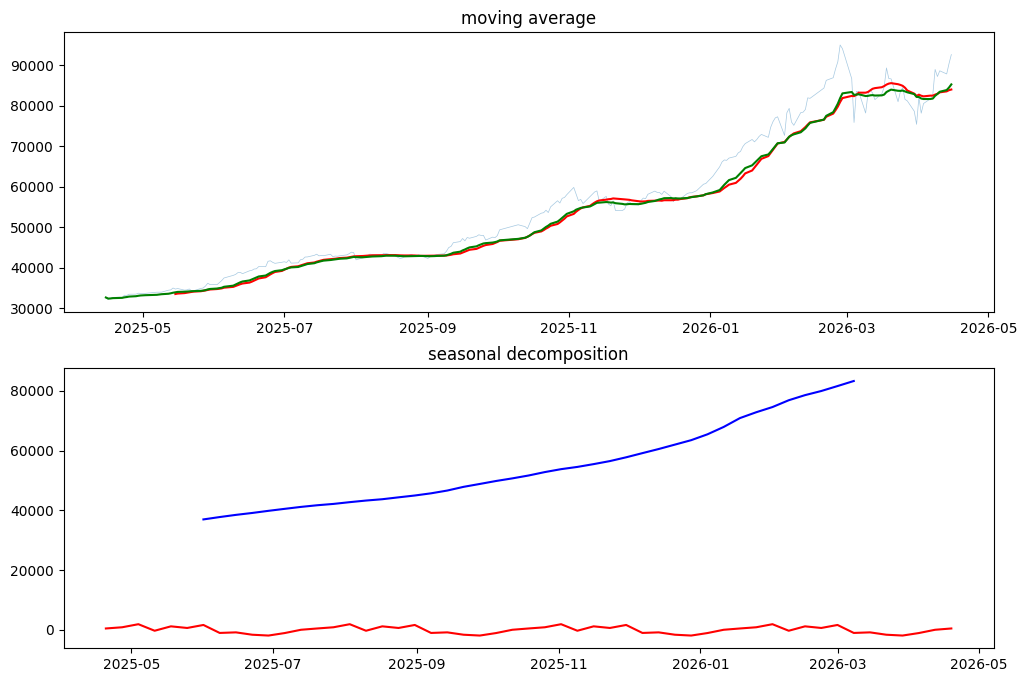

In [ ]:
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
ax = axes[0]
ax.plot(close.index, close, alpha=0.4, linewidth=0.5, label="original")
ax.plot(sma_20.index, sma_20, linewidth=1.5, label="sma", color="red")
ax.plot(ema_20.index, ema_20, linewidth=1.5, label="ema", color="green")
ax.set_title("moving average")

weekly = close.resample("W").last().dropna()
decomp = seasonal_decompose(weekly, model="additive", period=13)
axes[1].plot(
    decomp.trend.index, decomp.trend, label="trend", linewidth=1.5, color="blue"
)
axes[1].plot(
    decomp.seasonal.index, decomp.seasonal, label="seasonal", linewidth=1.5, color="red"
)
axes[1].set_title("seasonal decomposition")
plt.show()

In [35]:
import pandas as pd

tickers = {
    "069500": "KODEX 200 (국내주식)",
    "360750": "TIGER S&P500 (미국주식)",
    "152380": "KODEX 국고채10년 (채권)",
    "132030": "KODEX 골드선물 (원자재)",
}

multi_close = pd.DataFrame()
for ticker, name in tickers.items():
    df = fdr.DataReader(ticker, start_date, end_date)
    multi_close[name] = df["Close"]

multi_close.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-15,32692,18972,70736,19189
2025-04-16,32183,18720,70899,19582
2025-04-17,32501,18616,70860,19806
2025-04-18,32722,18621,70993,19851
2025-04-21,32766,18334,71127,20135


In [37]:
multi_close = multi_close.dropna()
returns = multi_close.pct_change().dropna()
returns.head()

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-16,-0.015570,-0.013283,0.002304,0.020480
2025-04-17,0.009881,-0.005556,-0.000550,0.011439
2025-04-18,0.006800,0.000269,0.001877,0.002272
2025-04-21,0.001345,-0.015413,0.001888,0.014307
2025-04-22,-0.003296,-0.009436,-0.001111,0.028408


In [ ]:
cum_returns = (1 + returns).cumprod()
cum_returns.head()


,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
Date,,,,
2025-04-16,0.984430,0.986717,1.002304,1.020480
2025-04-17,0.994158,0.981236,1.001753,1.032154
2025-04-18,1.000918,0.981499,1.003633,1.034499
2025-04-21,1.002264,0.966371,1.005528,1.049299
2025-04-22,0.998960,0.957253,1.004411,1.079108


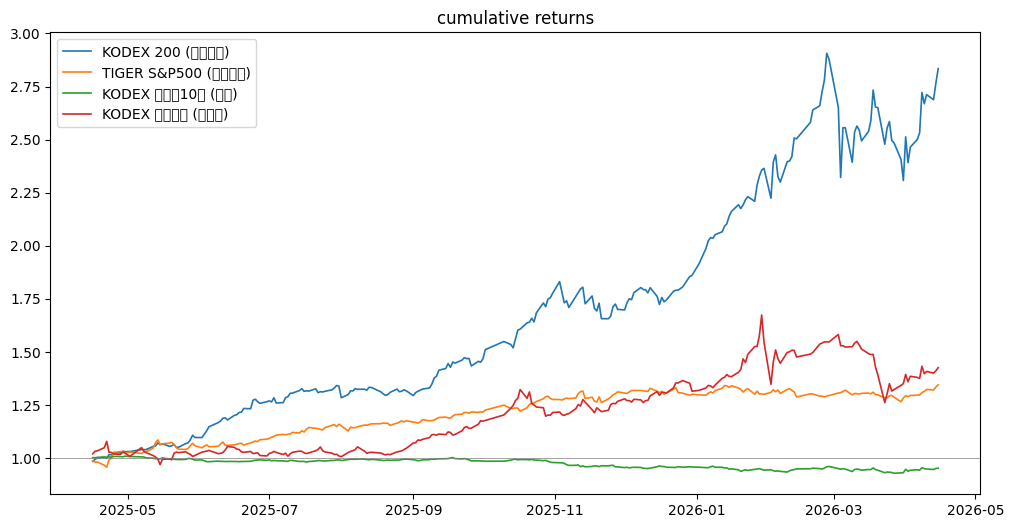

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col], label=col, linewidth=1.2)
ax.legend()
ax.axhline(1, color="grey", linewidth=0.5)
ax.set_title("cumulative returns")
plt.show()

In [57]:
corr_matrix = returns.corr()
corr_matrix

,KODEX 200 (국내주식),TIGER S&P500 (미국주식),KODEX 국고채10년 (채권),KODEX 골드선물 (원자재)
KODEX 200 (국내주식),1.000000,0.293541,0.389003,0.383096
TIGER S&P500 (미국주식),0.293541,1.000000,0.031366,-0.068603
KODEX 국고채10년 (채권),0.389003,0.031366,1.000000,0.165718
KODEX 골드선물 (원자재),0.383096,-0.068603,0.165718,1.000000


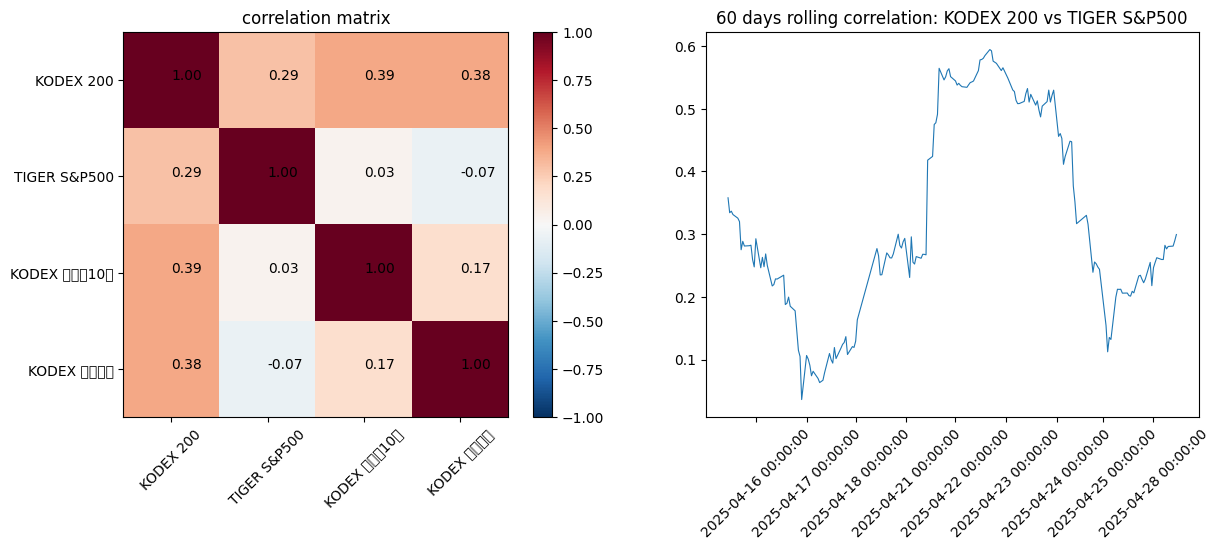

In [80]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
im = ax1.imshow(returns.corr(), cmap="RdBu_r", vmin=-1, vmax=1)
ax1.set_xticks(range(len(corr_matrix)))
ax1.set_yticks(range(len(corr_matrix)))
short_names = [c.split("(")[0].strip() for c in corr_matrix.columns]
ax1.set_xticklabels(short_names, rotation=45)
ax1.set_yticklabels(short_names)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax1.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}")
fig.colorbar(im, ax=ax1)
ax1.set_title("correlation matrix")

cols = returns.columns.tolist()
if len(cols) >= 2:
    rolling_corr = returns[cols[0]].rolling(60).corr(returns[cols[1]])
    ax2.plot(rolling_corr.index, rolling_corr, linewidth=0.8)
    ax2.set_xticklabels(rolling_corr.index, rotation=45)
    ax2.set_title(f"60 days rolling correlation: {short_names[0]} vs {short_names[1]}")

plt.show()


In [ ]:
import numpy as np


def cacl_matrics(returns_series, risk_free=0.035):
    ann_ret = (1 + returns_series.mean()) ** 252 - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = (ann_ret - risk_free) / ann_vol
    cum = (1 + returns_series).cumprod()
    mdd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {
        "yearly_return": f"{ann_ret:.2%}",
        "yearly_volatile": f"{ann_vol:.2%}",
        "MDD": f"{mdd * 10:.2%}",
        "sharpe": f"{sharpe:.2f}",
    }


metrics_rows = []
for col in returns.columns:
    m = cacl_matrics(returns[col])
    m["ETF"] = col.split("(")[0].strip()
    metrics_rows.append(m)

metrics_rows


[{'yearly_return': '214.96%',
  'yearly_volatile': '36.60%',
  'MDD': '-206.21%',
  'sharpe': '5.78',
  'ETF': 'KODEX 200'},
 {'yearly_return': '37.18%',
  'yearly_volatile': '13.35%',
  'MDD': '-56.88%',
  'sharpe': '2.52',
  'ETF': 'TIGER S&P500'},
 {'yearly_return': '-4.72%',
  'yearly_volatile': '5.67%',
  'MDD': '-80.02%',
  'sharpe': '-1.45',
  'ETF': 'KODEX 국고채10년'},
 {'yearly_return': '51.75%',
  'yearly_volatile': '31.06%',
  'MDD': '-246.69%',
  'sharpe': '1.55',
  'ETF': 'KODEX 골드선물'}]

In [109]:
metrics_df = pd.DataFrame(metrics_rows).set_index("ETF")
metrics_df

,yearly_return,yearly_volatile,MDD,sharpe
ETF,,,,
KODEX 200,214.96%,36.60%,-206.21%,5.78
TIGER S&P500,37.18%,13.35%,-56.88%,2.52
KODEX 국고채10년,-4.72%,5.67%,-80.02%,-1.45
KODEX 골드선물,51.75%,31.06%,-246.69%,1.55


In [124]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()
llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    temperature=0.3,
    max_tokens=400,
)


def generate_analysis_insight(metrics_df):
    response = llm.invoke(
        [
            {
                "role": "system",
                "content": "당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다",
            },
            {
                "role": "user",
                "content": f"""아래 ETF 비교 데이터를 분석하여 투자 인사이트를 작성하세요.
        
        {metrics_df.to_string()}
        
        다음 형식으로 답하세요:
        1. 핵심 발견(3줄)
        2. 위험 요인(2줄)
        3. 분산 투자 제안(2줄)""",
            },
        ]
    )
    return response.content

In [114]:
insight = generate_analysis_insight(metrics_df)

In [ ]:
from scipy.stats import skew, kurtosis


def generate_analysis_report(ticker_name, close_prices):
    returns = close_prices.pct_change().dropna()
    sma_20 = close_prices.rolling(20).mean().iloc[-1]
    sma_60 = close_prices.rolling(60).mean().iloc[-1]
    current = close_prices.iloc[-1]
    rolling_mean = returns.rolling(30).mean()
    rolling_std = returns.rolling(30).std()
    z_latest = ((returns - rolling_mean) / rolling_std).iloc[-1]

    sk = skew(returns.dropna())
    kt = kurtosis(returns.dropna())

    vol_recent = returns[-20:].std() * np.sqrt(252) * 100
    vol_overall = returns.std() * np.sqrt(252) * 100

    context = f"""
    현재가: {current:.2f}
    20일 이동평균: {sma_20:.2f}
    60일 이동평균: {sma_60:.2f}
    최근 20일 변동성: {vol_recent:.2f}%
    전체 기간 변동성: {vol_overall:.2f}%
    최근 20일 최근 수익률: {returns[-20:].mean() * 100:.2f}%
    최근 20일 z-score: {z_latest:.2f}
    최근 20일 skewness: {sk:.2f}
    최근 20일 kurtosis: {kt:.2f}
    """

    response = llm.invoke(
        [
            {
                "role": "system",
                "content": "당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다",
            },
            {
                "role": "user",
                "content": f"""
                이 시계열 분석 지표를 바탕으로 {ticker_name}의 현재 상태를 2~3문장으로 요약해주세요.
                {context}
                투자 추천은 하지마세요. 객관적 현황만 서술해주세요
                """,
            },
        ]
    )

    return response.content


generate_analysis_report("KODEX 200 (국내주식)", close)

'KODEX 200의 현재가는 92,665.00으로, 20일 이동평균(84,036.00)과 60일 이동평균(81,552.23)보다 상당히 높은 수준에 있습니다. 최근 20일 변동성(62.45%)은 전체 기간 변동성(36.60%)보다 높아 시장의 불안정성을 나타내며, 최근 20일 수익률은 0.25%로 미미한 상승세를 보이고 있습니다. Z-score(0.41)는 평균에 비해 다소 높은 수준을 나타내며, skewness(-0.57)와 kurtosis(6.65)는 분포가 왼쪽으로 치우쳐 있고, 극단적인 값이 존재함을 시사합니다.'

In [ ]:
def generate_analysis_report_llm_only(ticker_name, close_prices):
    recent_prices = close_prices.tail(120).tolist()
    prompt = f"""
  다음은 {ticker_name}의 최근 120일간의 종가 데이터입니다.
  {recent_prices}
  이 데이터를 바탕으로 투자 인사이트를 작성해주세요.
  - 추세(상승/하락/횡보)
  - 변동성 특징
  - 최근 이상 움직임 여부
  
  투자 추천은 하지마세요. 객관적 현황만 서술해주세요
  """
    response = llm.invoke(
        [
            {
                "role": "system",
                "content": "당신은 금융 데이터 분석가입니다. 수치 기반으로 직관적인 인사이트를 제공합니다",
            },
            {"role": "user", "content": prompt},
        ]
    )

    return response.content


generate_analysis_report_llm_only("KODEX 200 (국내주식)", close)

'KODEX 200의 최근 120일간 종가 데이터를 분석한 결과는 다음과 같습니다.\n\n### 1. 추세\n- **상승 추세**: 전체적으로 KODEX 200의 종가는 120일 동안 상승세를 보였습니다. 특히, 데이터의 초반부인 53626에서 시작하여 92665까지 상승하는 모습을 확인할 수 있습니다. 중간에 몇 차례의 조정이 있었지만, 전반적으로 상승세가 지속되었습니다.\n- **단기 조정**: 80일 경과 후에는 종가가 89000 근처에서 약간의 조정이 있었으며, 이는 단기적으로 하락세를 보였으나, 이후 다시 상승세로 전환되었습니다.\n\n### 2. 변동성 특징\n- **변동성 증가**: 초기에는 비교적 안정적인 상승세를 보였으나, 중반부부터 후반부로 갈수록 변동성이 증가하는 경향을 보였습니다. 특히, 80000 이상의 가격대에서 큰 폭의 변동이 관찰되었습니다.\n- **최고점과 최저점**: 최고점은 95025로, 최근 30일간의 종가에서 가장 높은 수치입니다. 반면, 최저점은 53626으로, 초기 데이터에서 나타났습니다. 이로 인해 전체적인 변동폭은 약 41399로 상당히 큰 편입니다.\n\n### 3. 최근 이상 움직임 여부\n- **이상 움직임**: 최근 30일 동안 종가가 89000을 초과한 후, 다시 80000대 초반으로 하락하는 패턴이 관찰되었습니다. 이는 시장의 불확실성이나 외부 요인에 의한 조정으로 해석될 수 있습니다.\n- **거래량 및 시장 반응**: 종가의 급격한 변화'

In [ ]:
kodex = fdr.DataReader(
    "069500", start=(datetime.now() - timedelta(days=180)).strftime("%Y-%m-%d")
)
tiger = fdr.DataReader(
    "360750", start=(datetime.now() - timedelta(days=180)).strftime("%Y-%m-%d")
)
bond = fdr.DataReader(
    "152380", start=(datetime.now() - timedelta(days=180)).strftime("%Y-%m-%d")
)

In [ ]:
combined = pd.concat(
    [
        kodex["Close"].rename("kodex"),
        tiger["Close"].rename("tiger"),
        bond["Close"].rename("bond"),
    ],
    axis=1,
)
combined.head()

,kodex,tiger,bond
Date,,,
2025-10-17,52550,23157,70266
2025-10-20,53511,23480,70246
2025-10-21,53626,23773,70172
2025-10-22,54234,23868,70326
2025-10-23,53661,23888,70113


In [ ]:
meta = pd.DataFrame(
    [
        {
            "ticker": "069500",
            "name": "KODEX 200",
            "category": "국내주식",
            "expense": 0.15,
        },
        {
            "ticker": "360750",
            "name": "TIGER S&P500",
            "category": "해외주식",
            "expense": 0.07,
        },
        {
            "ticker": "152380",
            "name": "KODEX 국고채10년",
            "category": "채권",
            "expense": 0.05,
        },
        {
            "ticker": "132030",
            "name": "KODEX 골드선물",
            "category": "원자재",
            "expense": 0.68,
        },
    ]
)

analysis = pd.DataFrame(
    [
        {"ticker": "069500", "sharpe": 0.82, "mdd": -0.15},
        {"ticker": "360750", "sharpe": 1.25, "mdd": -0.12},
        {"ticker": "152380", "sharpe": 0.31, "mdd": -0.05},
        {"ticker": "132030", "sharpe": 0.95, "mdd": -0.08},
    ]
)

In [ ]:
pd.merge(meta, analysis, on="ticker")

,ticker,name,category,expense,sharpe,mdd
0,069500,KODEX 200,국내주식,0.15,0.82,-0.15
1,360750,TIGER S&P500,해외주식,0.07,1.25,-0.12
2,152380,KODEX 국고채10년,채권,0.05,0.31,-0.05
3,132030,KODEX 골드선물,원자재,0.68,0.95,-0.08


In [ ]:
price_dict = {
    "069500": kodex,
    "360750": tiger,
    "152380": bond,
}


def merge_df(price_dict, meta):
    # price_dict에 있는 ticker 들의 close
    closes = pd.concat(
        {ticker: df["Close"] for ticker, df in price_dict.items()}, axis=1
    ).dropna()
    # price_dict에 있는 close들의 annual return
    analysis_rows = []
    for ticker in closes.columns:
        ret = closes[ticker].pct_change().dropna()
        ann_ret = (1 + ret.mean()) ** 252 - 1
        analysis_rows.append(
            {"ticker": ticker, "annual_return": round(ann_ret * 100, 2)}
        )
    analysis_df = pd.DataFrame(analysis_rows)

    result = pd.merge(meta, analysis_df, on="ticker")
    return result


merged_df = merge_df(price_dict, meta).head()
merged_df

,ticker,name,category,expense,annual_return
0,069500,KODEX 200,국내주식,0.15,266.71
1,360750,TIGER S&P500,해외주식,0.07,23.44
2,152380,KODEX 국고채10년,채권,0.05,-8.05


In [ ]:
long_data = []
for ticker, name in [
    ("069500", "KODEX200"),
    ("360750", "TIGER_SP500"),
    ("152380", "KODEX_국고채"),
]:
    df = price_dict.get(ticker)
    if df is None:
        continue
    ret = df["Close"].pct_change().dropna()
    for date, val in ret.items():
        long_data.append(
            {
                "date": date,
                "ticker": ticker,
                "name": name,
                "return": val,
                "weekday": date.strftime("%a"),
                "month": date.month,
            }
        )
long_df = pd.DataFrame(long_data)
long_df.head()


Long format: (363, 6)


In [ ]:
summary = long_df.groupby("name")["return"].agg(
    변동수익률="mean", 변동성="std", 최대="max", 최소="min", 거래일수="count"
)
summary

,변동수익률,변동성,최대,최소,거래일수
name,,,,,
KODEX200,0.005170,0.030692,0.101054,-0.124618,121
KODEX_국고채,-0.000333,0.004464,0.017152,-0.012295,121
TIGER_SP500,0.000836,0.008290,0.018928,-0.026759,121


In [162]:
pd.pivot_table(long_df, values="return", index="name", columns="month", aggfunc="mean")

month,1,2,3,4,10,11,12
name,,,,,,,
KODEX200,0.011545,0.012140,-0.009222,0.019562,0.010145,-0.001922,0.004390
KODEX_국고채,-0.000733,0.001072,-0.001459,0.002117,-0.001392,-0.001065,-0.000026
TIGER_SP500,0.000011,-0.000227,-0.000399,0.004286,0.004504,0.001442,-0.000375


In [ ]:
vol_pivot = pd.pivot_table(
    long_df, values="return", index="name", columns="month", aggfunc="std"
)
vol_pivot

month,1,2,3,4,10,11,12
name,,,,,,,
KODEX200,0.011950,0.032510,0.051126,0.039064,0.013681,0.023680,0.013825
KODEX_국고채,0.003706,0.003513,0.005920,0.007791,0.002383,0.003578,0.002856
TIGER_SP500,0.007987,0.008705,0.007879,0.004493,0.007038,0.011211,0.007453


In [165]:
stacked = vol_pivot.stack()
stacked

name         month
KODEX200     1        0.011950
             2        0.032510
             3        0.051126
             4        0.039064
             10       0.013681
             11       0.023680
             12       0.013825
KODEX_국고채    1        0.003706
             2        0.003513
             3        0.005920
             4        0.007791
             10       0.002383
             11       0.003578
             12       0.002856
TIGER_SP500  1        0.007987
             2        0.008705
             3        0.007879
             4        0.004493
             10       0.007038
             11       0.011211
             12       0.007453
dtype: float64